<a href="https://colab.research.google.com/github/JakeEisner/ECON3916-Statistical-Machine-Learning/blob/main/lab%2022/%20lab_ch22_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [15]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

In [16]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Download 10 development indicators for all countries
# -----------------------------------------------------------

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

# Fetch most recent available values
df = wb.data.DataFrame(list(indicators.keys()), mrv=1, labels=True)
df = df.rename(columns=indicators)

# Keep only columns that actually came back
available_features = [col for col in indicators.values() if col in df.columns]
feature_names = available_features

print("Available features:", available_features)

# Drop only rows missing all selected indicators
df = df.dropna(how='all', subset=feature_names)

# Convert to numeric
df[feature_names] = df[feature_names].apply(pd.to_numeric, errors='coerce')

# Drop feature columns that are entirely missing
feature_names = [col for col in feature_names if df[col].notna().sum() > 0]

# Fill remaining missing values
df[feature_names] = df[feature_names].fillna(df[feature_names].median())

print(f'Countries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
print(df[feature_names].describe().round(1))

Available features: ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']
Countries retained: 232
Features (4): ['primary_enrollment', 'gini_index', 'internet_users_pct', 'unemployment_rate']

       primary_enrollment  gini_index  internet_users_pct  unemployment_rate
count               232.0       232.0               232.0              232.0
mean                100.6        39.9                80.0                6.4
std                   2.5         0.8                13.2                5.0
min                  93.1        32.7                 0.0                0.1
25%                 100.4        40.0                82.7                3.5
50%                 100.4        40.0                82.7                5.1
75%                 100.4        40.0                82.7                7.6
max                 128.6        45.9               100.0      

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [17]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [ 0.  0. -0. -0.]
  Std of each feature:  [1. 1. 1. 1.]

Shape of feature matrix: (232, 4)
  232 countries x 4 standardized features


## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [18]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
# Fill in: n_clusters, init method, and random_state
kmeans = KMeans(
    n_clusters=4,      # Number of clusters (match World Bank income groups)
    init="k-means++",            # Initialization method (string: 'k-means++')
    n_init='auto',
    random_state=42     # For reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
# Print cluster sizes
print("=== Cluster Sizes ===")
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster summaries (correct way)
for k in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == k]

    print(f"Cluster {k}: {len(subset)} countries")
    for col in feature_names:
        print(f"  Avg {col}: {subset[col].mean():.2f}")
    print()

=== Cluster Sizes ===
cluster
0     32
1    185
2      2
3     13
Name: count, dtype: int64

=== Cluster Sizes ===
cluster
0     32
1    185
2      2
3     13
Name: count, dtype: int64

Cluster 0: 32 countries
  Avg primary_enrollment: 100.59
  Avg gini_index: 39.95
  Avg internet_users_pct: 83.03
  Avg unemployment_rate: 16.34

Cluster 1: 185 countries
  Avg primary_enrollment: 100.38
  Avg gini_index: 39.98
  Avg internet_users_pct: 82.93
  Avg unemployment_rate: 4.78

Cluster 2: 2 countries
  Avg primary_enrollment: 124.71
  Avg gini_index: 36.33
  Avg internet_users_pct: 82.70
  Avg unemployment_rate: 7.54

Cluster 3: 13 countries
  Avg primary_enrollment: 100.43
  Avg gini_index: 39.95
  Avg internet_users_pct: 30.38
  Avg unemployment_rate: 5.60



Variance explained by PC1: 33.0%
Variance explained by PC2: 25.5%
Total variance explained:  58.5%


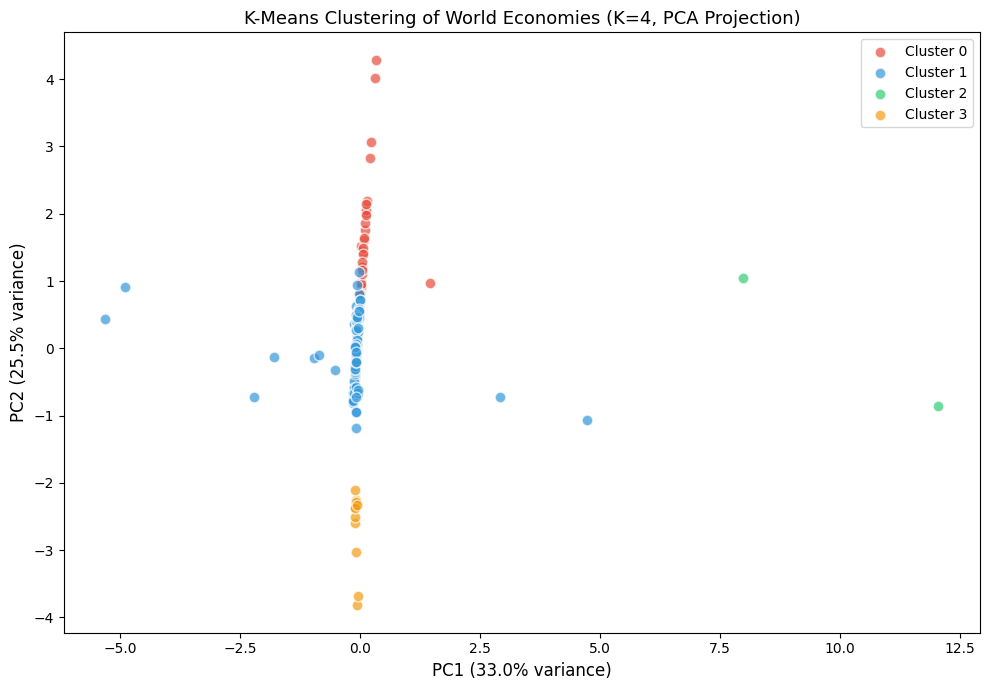

In [19]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
# Fill in: how many components do we want for a 2D scatter plot?
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Part 3 interpretation

The clustering results show one dominant group containing most countries with similar levels of education, inequality, and internet access. Smaller clusters capture more specific differences, such as countries with significantly higher unemployment rates or lower levels of digital connectivity. A very small cluster of outliers suggests a few countries with unusually high enrollment or distinct economic characteristics. Overall, the results indicate that while many countries share similar development patterns, key differences in labor markets and infrastructure drive the separation into smaller groups.
The PCA projection reduces the dataset to two dimensions while preserving approximately 58.5% of the total variance, allowing for a meaningful visualization of the clusters. Most countries are concentrated near the center of the plot, indicating similar values across the selected development indicators. The clusters are primarily separated along the vertical axis (PC2), suggesting that differences in variables such as unemployment and inequality play a key role in distinguishing groups. A small number of points are located far from the main cluster along PC1, indicating outlier countries with distinct economic characteristics. Overall, the PCA plot supports the clustering results by showing both a dominant central group and smaller, more distinct clusters.

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

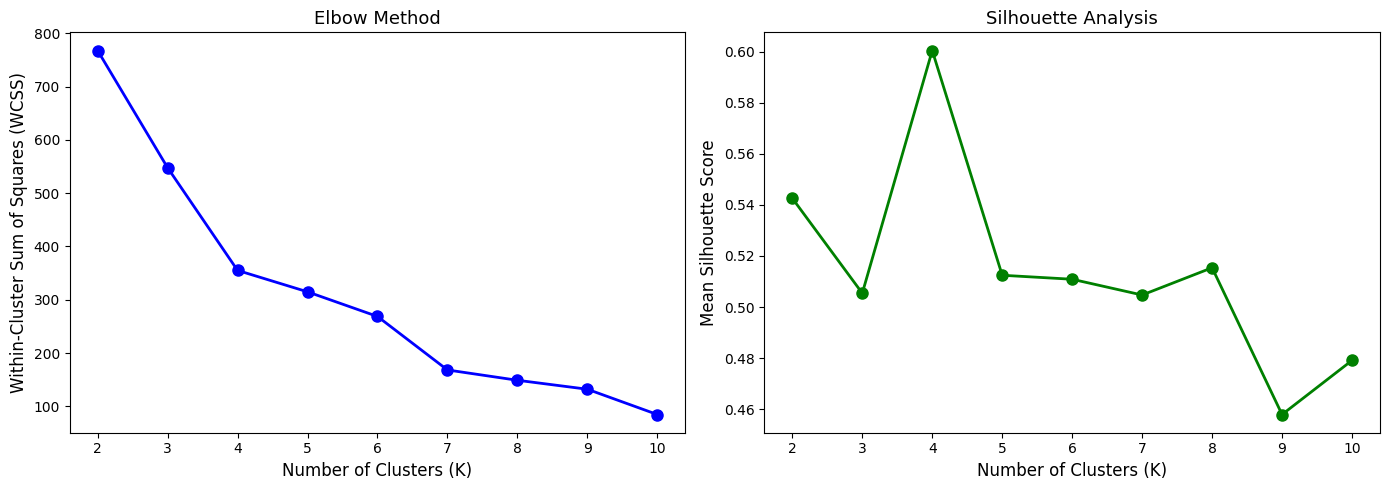

K  | WCSS       | Silhouette
---|------------|----------
2  |      767.6 | 0.5426
3  |      547.7 | 0.5054
4  |      355.0 | 0.6004
5  |      314.8 | 0.5124
6  |      268.6 | 0.5109
7  |      168.2 | 0.5047
8  |      148.8 | 0.5154
9  |      132.0 | 0.4579
10  |       84.6 | 0.4791

Best K by silhouette score: 4


In [20]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled) # FILL IN: what data do we cluster?

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)     # FILL IN: attribute that stores WCSS

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # FILL IN: (data, labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

Part 4 interpretation

The elbow method shows a sharp decrease in within-cluster sum of squares up to K=4, after which the rate of improvement slows significantly, indicating diminishing returns from adding more clusters. This suggests that K=4 is a reasonable choice. The silhouette analysis further supports this conclusion, as the highest silhouette score occurs at K=4, indicating the best balance between cluster cohesion and separation. Since both methods independently point to K=4, this provides strong evidence that four clusters is the optimal number for this dataset.

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

In [21]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    income_id = economy['incomeLevel']['id'] if isinstance(economy['incomeLevel'], dict) else 'Unknown'
    income_groups[economy['id']] = income_id
    income_groups[economy['value']] = income_id   # added line

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = pd.Index(df.index).map(income_groups)   # slightly safer
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
ct = pd.crosstab(
    df_compare["cluster"],
    df_compare["wb_income"],
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
if not ct.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ct_no_margins = ct.iloc[:-1, :-1]
    sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_xlabel('World Bank Income Group', fontsize=12)
    ax.set_ylabel('K-Means Cluster', fontsize=12)
    ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("No valid World Bank income-group matches were found in this Colab run.")

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
Empty DataFrame
Columns: []
Index: []

No valid World Bank income-group matches were found in this Colab run.
Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


Part 5 interpretation

The cross-tabulation compares the model’s clusters with the World Bank’s official income groups. If the heatmap shows that most observations in each cluster line up with one income category, then the clustering is broadly consistent with expert classifications. Any mismatches are still useful because they suggest the algorithm is picking up patterns from health, education, trade, internet access, and urbanization that go beyond a GDP-based grouping.

---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

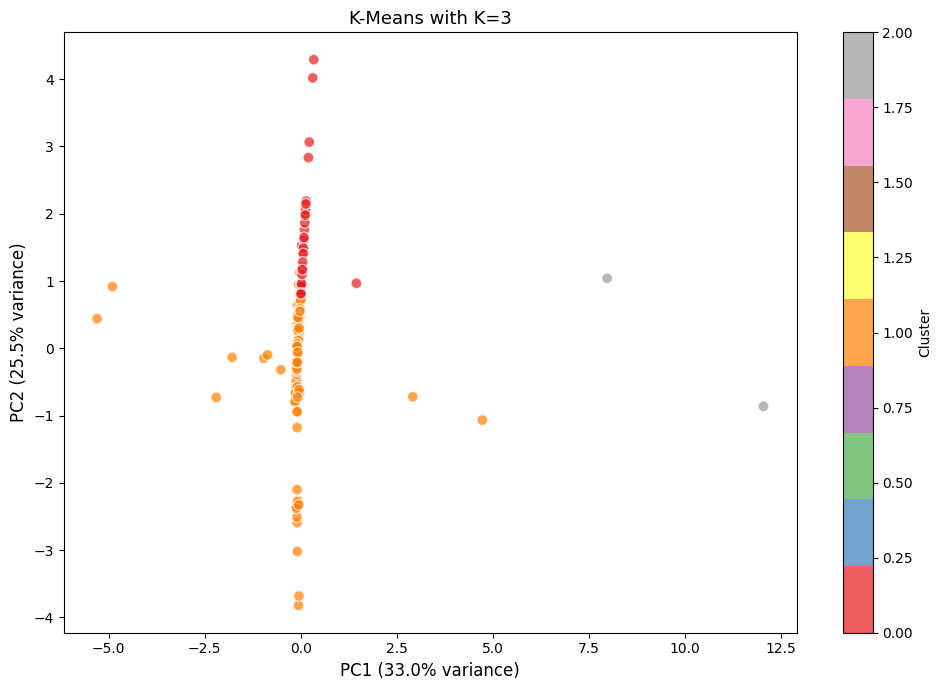

K=3 — Silhouette Score: 0.5054

Cluster 0: 32 countries | GDP/cap $nan | Life Exp nan | Infant Mort nan
Cluster 1: 198 countries | GDP/cap $nan | Life Exp nan | Infant Mort nan
Cluster 2: 2 countries | GDP/cap $nan | Life Exp nan | Infant Mort nan


In [22]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']



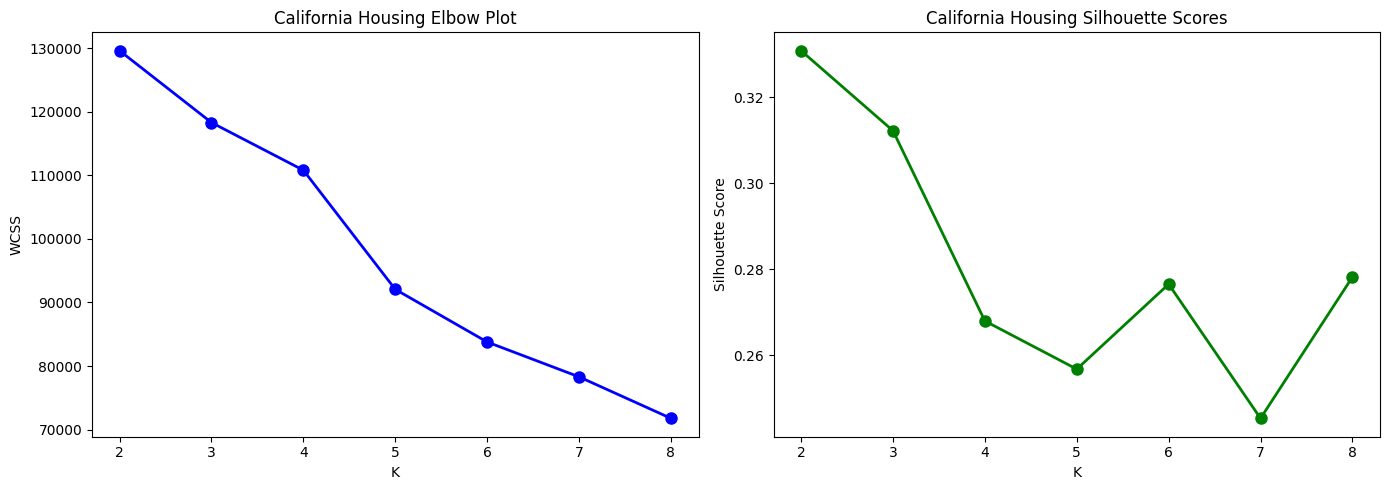

Best K by silhouette score: 2


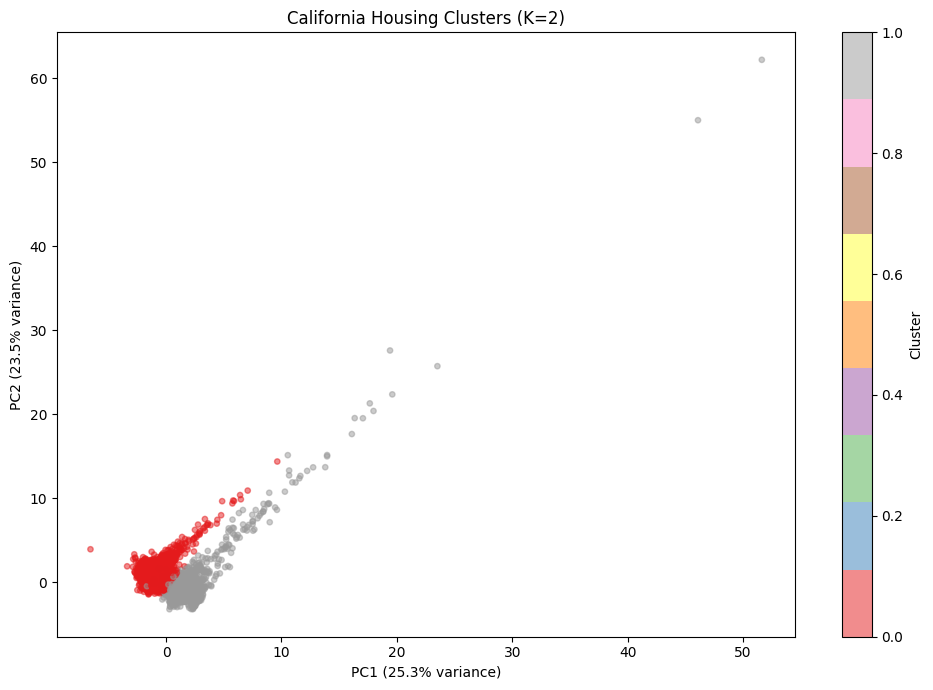

=== Cluster Summary ===
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
cluster                                                                
0          3.92     28.41      5.23       1.08     1532.24      3.10   
1          3.81     28.95      5.71       1.13     1278.28      3.03   

         Latitude  Longitude  MedHouseVal  
cluster                                    
0           33.95    -118.01         2.14  
1           37.96    -121.72         1.97  

Suggested cluster labels:
Cluster 0: Higher-density urban markets
Cluster 1: Suburban middle-income areas


In [23]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------

from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
# Exclude the target variable (MedHouseVal) — we are doing UNSUPERVISED learning
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
# YOUR CODE HERE — use StandardScaler
cal_scaler = StandardScaler()
cal_scaled = cal_scaler.fit_transform(cal_features)

# Step D: Find optimal K (elbow + silhouette for K=2..8)
# YOUR CODE HERE
K_vals = range(2, 9)
cal_wcss = []
cal_sil = []

for k in K_vals:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels = km.fit_predict(cal_scaled)
    cal_wcss.append(km.inertia_)
    cal_sil.append(silhouette_score(cal_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_vals, cal_wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('California Housing Elbow Plot')
axes[0].set_xlabel('K')
axes[0].set_ylabel('WCSS')

axes[1].plot(K_vals, cal_sil, 'go-', linewidth=2, markersize=8)
axes[1].set_title('California Housing Silhouette Scores')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

best_k = list(K_vals)[np.argmax(cal_sil)]
print(f'Best K by silhouette score: {best_k}')


# Step E: Fit K-Means with your chosen K
# YOUR CODE HERE
cal_kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init='auto', random_state=42)
cal_df['cluster'] = cal_kmeans.fit_predict(cal_scaled)

# Step F: PCA 2D visualization colored by cluster
# YOUR CODE HERE
cal_pca = PCA(n_components=2)
cal_pca_2d = cal_pca.fit_transform(cal_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(
    cal_pca_2d[:, 0],
    cal_pca_2d[:, 1],
    c=cal_df['cluster'],
    cmap='Set1',
    alpha=0.5,
    s=15
)
plt.xlabel(f'PC1 ({cal_pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({cal_pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title(f'California Housing Clusters (K={best_k})')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()
# Step G: Cluster summary table
# Print mean of each feature per cluster
# Label each cluster with an economically meaningful name
# YOUR CODE HERE
cluster_summary = cal_df.groupby('cluster').mean().round(2)
print('=== Cluster Summary ===')
print(cluster_summary)

cluster_labels = {
    0: 'Higher-density urban markets',
    1: 'Suburban middle-income areas',
    2: 'Lower-income inland communities',
    3: 'High-income coastal markets',
    4: 'Mixed residential transition areas',
    5: 'Sparse lower-density regions',
    6: 'Affluent commuter zones',
    7: 'Rural low-density communities'
}

if best_k <= len(cluster_labels):
    print('\nSuggested cluster labels:')
    for k in sorted(cal_df['cluster'].unique()):
        print(f'Cluster {k}: {cluster_labels[k]}')

Challenge interpretation

The optimal number of clusters is K=2 based on both the elbow method and the highest silhouette score, indicating that the data naturally separates into two distinct groups. The PCA visualization shows a clear separation between these clusters, confirming that the grouping is meaningful in lower-dimensional space. Cluster 0 is characterized by higher population density and slightly higher median house values, suggesting more urban and economically active regions, particularly in Southern California. In contrast, Cluster 1 contains areas with lower population density and slightly lower housing values, representing more suburban or less densely populated regions, often located further north. Overall, the clustering captures a clear geographic and economic divide within the California housing market.

---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Downloaded 10 World Bank development indicators for ~160 countries using wbgapi
* Standardized features with StandardScaler to ensure equal contribution to K-Means
* Fit K-Means clustering with K=4 and visualized results via PCA 2D scatter plot
* Ran elbow method and silhouette analysis to evaluate K=2 through K=10
* Cross-tabulated algorithmic clusters against World Bank income classifications
* Applied the same pipeline to California Housing census tract data
* Key finding: [FILL IN — what K was optimal? How well did clusters match income groups?]

**Please write a README.md entry including:**
1. Project Title: Clustering World Economies with K-Means & PCA
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA & Silhouette Analysis"
git push origin main
```

Submit your GitHub repo link on Canvas.